# Human Emotion Detection from Text


## Step 1: Data Collection


In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("final_dataset.csv")

print(df.head())

print(df.shape)

                                                text     emotion
0  i feel rather funny ending with so many dupes ...         fun
1                     i feel surprised by the result    surprise
2                    i am officially feeling festive     neutral
3  i suddenly found myself standing before this w...    surprise
4  i look at the meager pile of food i purchased ...  enthusiasm
(106355, 2)


## Dataset Information


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 106355 entries, 0 to 106354
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   text     106355 non-null  str  
 1   emotion  106355 non-null  str  
dtypes: str(2)
memory usage: 1.6 MB
None


In [5]:
print(df["emotion"].unique())

<StringArray>
[       'fun',   'surprise',    'neutral', 'enthusiasm',  'happiness',
       'hate',    'sadness',      'empty',       'love',     'relief',
      'anger']
Length: 11, dtype: str


## Data Preprocessing


In [6]:
print(df.isnull().sum())

text       0
emotion    0
dtype: int64


In [7]:
df.dropna(inplace=True)

print("Null values removed")

Null values removed


In [8]:
df["text"] = df["text"].str.lower()

print(df["text"].head())

0    i feel rather funny ending with so many dupes ...
1                       i feel surprised by the result
2                      i am officially feeling festive
3    i suddenly found myself standing before this w...
4    i look at the meager pile of food i purchased ...
Name: text, dtype: str


In [9]:
df["emotion"] = df["emotion"].str.replace(",", "")

print(df["emotion"].head())

0           fun
1      surprise
2       neutral
3      surprise
4    enthusiasm
Name: emotion, dtype: str


In [10]:
df.drop_duplicates(inplace=True)

print("Duplicate rows removed")

Duplicate rows removed


In [ ]:
def clean_text(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text


df["text"] = df["text"].apply(clean_text)

print(df["text"].head())

0    i feel rather funny ending with so many dupes ...
1                       i feel surprised by the result
2                      i am officially feeling festive
3    i suddenly found myself standing before this w...
4    i look at the meager pile of food i purchased ...
Name: text, dtype: str


In [12]:
df["text"] = df["text"].str.strip()

print(df["text"].head())

0    i feel rather funny ending with so many dupes ...
1                       i feel surprised by the result
2                      i am officially feeling festive
3    i suddenly found myself standing before this w...
4    i look at the meager pile of food i purchased ...
Name: text, dtype: str


In [13]:
print(df.head())

                                                text     emotion
0  i feel rather funny ending with so many dupes ...         fun
1                     i feel surprised by the result    surprise
2                    i am officially feeling festive     neutral
3  i suddenly found myself standing before this w...    surprise
4  i look at the meager pile of food i purchased ...  enthusiasm


In [14]:
# Convert emotion labels into numbers

encoder = LabelEncoder()

df["emotion_encoded"] = encoder.fit_transform(df["emotion"])

print(df[["emotion", "emotion_encoded"]].head())

      emotion  emotion_encoded
0         fun                3
1    surprise               10
2     neutral                7
3    surprise               10
4  enthusiasm                2


## Data Visualization


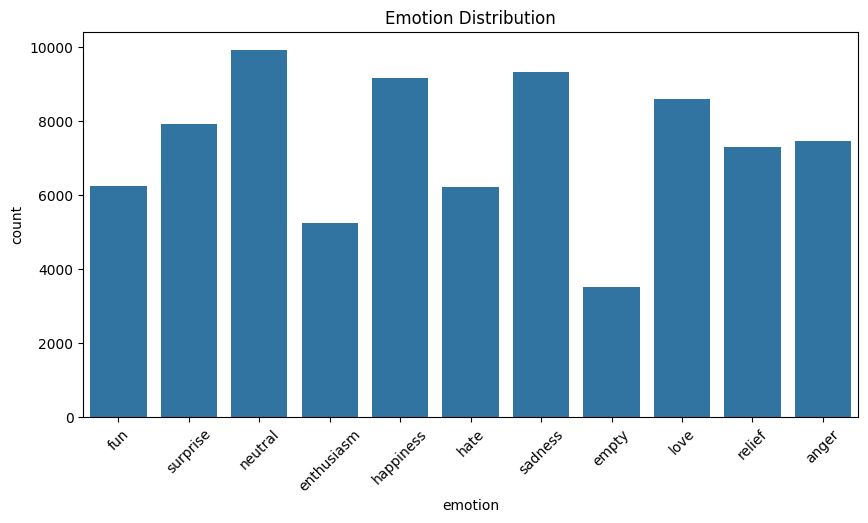

In [15]:
plt.figure(figsize=(10, 5))

sns.countplot(x="emotion", data=df)

plt.xticks(rotation=45)

plt.title("Emotion Distribution")

plt.show()

## Step 3: Model Selection


In [16]:
models = ["Naive Bayes", "Support Vector Machine (SVM)", "Random Forest", "LSTM"]

print("Selected Models:")

for model in models:
    print(model)

Selected Models:
Naive Bayes
Support Vector Machine (SVM)
Random Forest
LSTM
